In [ ]:
#Imports:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from shapash.explainer.smart_explainer import SmartExplainer

#Carregamento e Preparação:

#1. Configurar caminhos
base_path = os.getcwd()
if os.path.basename(base_path) == 'notebooks':
    data_path = "../data/nasa/nasa_cmapss_fd001_processed.csv"
    docs_path = "../docs/nasa"
else:
    data_path = "data/nasa/nasa_cmapss_fd001_processed.csv"
    docs_path = "docs/nasa"

os.makedirs(docs_path, exist_ok=True)

#2. Carregar Dados
df = pd.read_csv(data_path)
print(f"Dataset carregado: {df.shape[0]} amostras.")

#3. Separar Features (X) e Target (y)
#Obs.: Não usar 'engine_id' nem 'time_cycle' para prever, senão o modelo "rouba"
X = df.drop(['RUL', 'engine_id', 'time_cycle'], axis=1)
y = df['RUL']

#4. Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")

c:\XAILabProcess\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset carregado: 20631 amostras.
Treino: 16504 | Teste: 4127


In [ ]:
#Treinamento e avaliação:

#1. Treinando o modelo de Regressãoo (RF Regressor)

print("Treinando Random Forest Regressor...")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

#2. Avaliação

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Erro Médio Absoluto (MAE): {mae:.2f} ciclos (voos)")
print(f"Raiz do Erro Quadrático (RMSE): {rmse:.2f} ciclos")

#3. Salvando métricas para o MLflow

arquivo_metricas = os.path.join(docs_path, "3_Nasa_Metricas.txt")

with open(arquivo_metricas, 'w', encoding='utf-8') as f:
    f.write("Relatório de Performance (NASA C-MAPSS)\n")
    f.write(f"Modelo: Random Forest Regressor\n")
    f.write(f"MAE (Erro Medio Absoluto): {mae:.4f}\n")
    f.write(f"RMSE: {rmse:.4f}\n")

print(f"Métricas salvas em: {arquivo_metricas}")

Treinando Random Forest Regressor...
------------------------------
Erro Médio Absoluto (MAE): 29.69 ciclos (voos)
Raiz do Erro Quadrático (RMSE): 41.52 ciclos
------------------------------
Métricas salvas em: ../docs/nasa\3_Nasa_Metricas.txt


Score R² (Coeficiente de Determinação): 0.6227


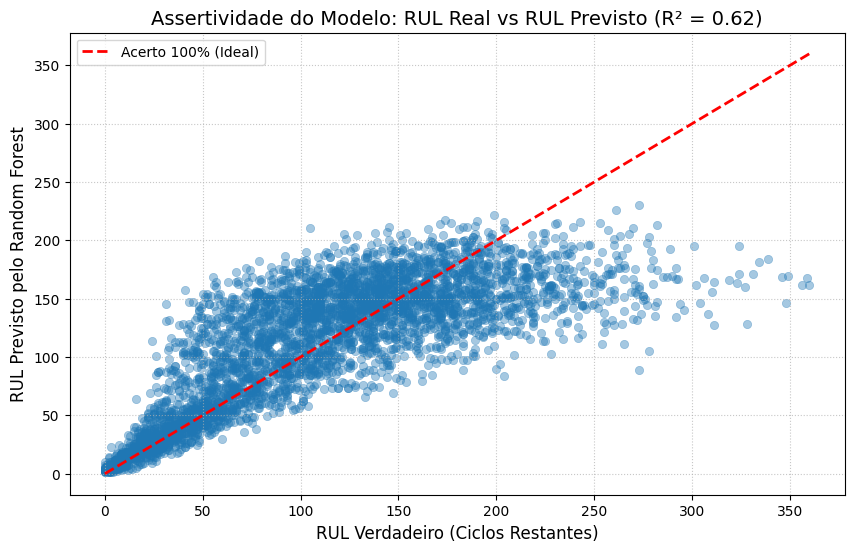

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

#1. Calculando o R^2
r2 = r2_score(y_test, y_pred)
print(f"Score R^2 (Coeficiente de Determinação): {r2:.4f}")

#2. Criando o Gráfico de Dispersão
plt.figure(figsize=(10, 6))

#Plotando os pontos (cada ponto é um instante de voo de um motor)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='#1f77b4', edgecolor=None)

#Criando a linha de comparação
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Acerto 100% (Ideal)')

#Formatação do gráfico
plt.title(f'Assertividade do Modelo: RUL Real vs RUL Previsto (R² = {r2:.2f})', fontsize=14)
plt.xlabel('RUL Verdadeiro (Ciclos Restantes)', fontsize=12)
plt.ylabel('RUL Previsto pelo Random Forest', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

#Salvando
plt.savefig('../docs/nasa/Verificacao_RUL_Real_vs_Predito.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Geração de Artefatos e configuração da biblioteca Shapash:

#1. Configurar Dicionário de Features

features_dict = {
    'sensor_2': 'Temp. Saída Compressor Baixa (°R)',
    'sensor_3': 'Temp. Saída Compressor Alta (°R)',
    'sensor_4': 'Temp. Saída Turbina Baixa (°R)',
    'sensor_7': 'Pressão Saída Compressor Alta (psia)',
    'sensor_11': 'Pressão Estática Saída HPC (psia)',
    'sensor_15': 'Razão de Combustível/Ar',
    'sensor_21': 'Velocidade Turbina (rpm)'
}

#2. Otimização da amostragem:

#400 linhas aleatórias do teste para explicar.
X_test_sample = X_test.sample(n=400, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

#3. Inicialização do Shapash:
xpl = SmartExplainer(
    model=model,
    features_dict=features_dict
)

#4. Compilação das explicações matemáticas usando apenas a amostra
print("Compilando XAI (Shapash) em amostra reduzida")
xpl.compile(x=X_test_sample, y_target=y_test_sample)

#5. Export dos gráficos para o MLflow
arquivo_feature_importance = os.path.join(docs_path, "1_Nasa_Feature_Importance.html")
xpl.plot.features_importance().write_html(arquivo_feature_importance)
print("Artefatos HTML gerados com sucesso na pasta docs/nasa!")

Compilando XAI (Shapash) em amostra reduzida


In [ ]:
#Dashboard Interativo:
print("Dashboard pronto!")
print("Link abaixo para abrir:")

app = xpl.run_app(
    title_story="Monitoramento Turbofan NASA - Prognóstico de Vida Útil",
    port=8050
)

----------------------------------------
DASHBOARD PRONTO!
Clique no link abaixo para abrir
Para parar, clique no botão 'Interromper' (quadrado) no menu superior.
----------------------------------------


INFO:root:Your Shapash application run on http://AcerA5-JR:8050/
INFO:root:Use the method .kill() to down your app.


Exception in thread Thread-47 (<lambda>):
Traceback (most recent call last):
  File "c:\XAILabProcess\.venv\lib\site-packages\urllib3\connection.py", line 204, in _new_conn
    sock = connection.create_connection(
  File "c:\XAILabProcess\.venv\lib\site-packages\urllib3\util\connection.py", line 85, in create_connection
    raise err
  File "c:\XAILabProcess\.venv\lib\site-packages\urllib3\util\connection.py", line 73, in create_connection
    sock.connect(sa)
OSError: [WinError 10049] O endereço solicitado não é válido no contexto

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\XAILabProcess\.venv\lib\site-packages\urllib3\connectionpool.py", line 787, in urlopen
    response = self._make_request(
  File "c:\XAILabProcess\.venv\lib\site-packages\urllib3\connectionpool.py", line 493, in _make_request
    conn.request(
  File "c:\XAILabProcess\.venv\lib\site-packages\urllib3\connection.py", line 500, in request
    sel